# **Linear Regression using NumPy**

In [15]:
import numpy as np

### 1. Dataset

In [16]:
X = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 3],
    [5, 5]
])

y = np.array([5, 4, 11, 10, 15])

### 2. Defining the model

In [17]:
def model(X, w, b):
    return X @ w + b

### 3. Defining the loss function

In [18]:
def mse(y, y_pred):
    return np.mean((y_pred - y) ** 2)

### 4. Defining the gradients

In [19]:
def gradients(X, y, w, b):
    n = len(X)
    y_pred = model(X, w, b)
    error = y_pred - y

    dw = ((2/n) * X.T @ error)
    db = ((2/n) * np.sum(error))

    return dw, db

### 5. Initializing $w$ and $b$

In [20]:
w = np.zeros(2)
b = 0

dw, db = gradients(X, y, w, b)

print(dw)
print(db)

[-64.4 -65.2]
-18.0


### 6. Training Loop

In [21]:
def train(X, y, learning_rate=0.01, epochs=1000, print_every=100):
    w = np.zeros(X.shape[1])
    b = 0
    loss_history = []

    for epoch in range(epochs):
        y_pred = model(X, w, b)
        loss = y_pred - y
        loss_history.append(loss)

        dw, db = gradients(X, y, w, b)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if (epoch + 1) % print_every == 0:
            mse = np.mean(loss ** 2)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {mse:.6f}")

    return np.array(w), b, lambda x: x @ w + b, loss_history

In [22]:
w, b, trained_model, loss_history = train(X, y, learning_rate=0.01)

Epoch 100/1000, Loss: 0.055168
Epoch 200/1000, Loss: 0.015750
Epoch 300/1000, Loss: 0.005622
Epoch 400/1000, Loss: 0.002423
Epoch 500/1000, Loss: 0.001167
Epoch 600/1000, Loss: 0.000592
Epoch 700/1000, Loss: 0.000307
Epoch 800/1000, Loss: 0.000161
Epoch 900/1000, Loss: 0.000084
Epoch 1000/1000, Loss: 0.000044


In [23]:
trained_model(X)

array([ 5.00926099,  4.00958583, 11.00017057, 10.00049541, 14.99351517])

### Visualizing MSE Loss 

In [24]:
import matplotlib.pyplot as plt

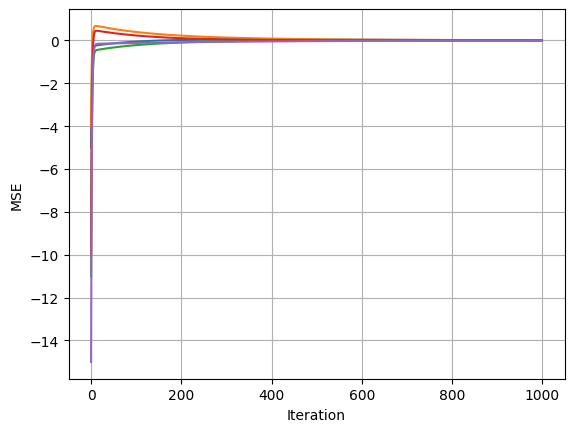

In [25]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid()
plt.show()